# 02 — Feature Engineering

## Objectif
Créer toutes les variables (features) que nos modèles utiliseront pour apprendre à prédire la consommation énergétique.

Notre rôle ici est de **traduire l'information temporelle en chiffres exploitables** car un modèle de de Machine Learning ne "voit" pas le temps, il voit plutot des chiffres.

## Plan
1. Features temporelles (heure, jour, mois, saison, jours fériés)
2. Features lag (consommation passée)
3. Features rolling (moyennes et écarts-types glissants)
4. Intégration des données météo (OpenWeatherMap)

In [1]:
# ============================================================
# 02 — FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

# Chargement des données nettoyées
df = pd.read_csv('../data/processed/pjme_clean.csv', 
                 index_col='Datetime', 
                 parse_dates=True)

print(" Données chargées")
print(f"Shape : {df.shape}")
print(f"Période : {df.index.min()} → {df.index.max()}")
print(f"\nAperçu :")
print(df.head())

 Données chargées
Shape : (145366, 2)
Période : 2002-01-01 01:00:00 → 2018-08-03 00:00:00

Aperçu :
                        PJME  is_outlier
Datetime                                
2002-01-01 01:00:00  30393.0           0
2002-01-01 02:00:00  29265.0           0
2002-01-01 03:00:00  28357.0           0
2002-01-01 04:00:00  27899.0           0
2002-01-01 05:00:00  28057.0           0


## 1️ Features Temporelles

Les modèles ML ne comprennent pas nativement le temps. On va donc extraire 
explicitement chaque composante temporelle utile. On va ajouté également les **jours fériés américains** car la consommation peut chuter significativement ces jours-là (comme le weekend).

In [2]:
# ============================================================
# Features temporelles
# ============================================================

from pandas.tseries.holiday import USFederalHolidayCalendar

# --- Composantes temporelles de base ---
df['hour']        = df.index.hour
df['dayofweek']   = df.index.dayofweek      # 0=Lundi, 6=Dimanche
df['month']       = df.index.month
df['quarter']     = df.index.quarter
df['year']        = df.index.year
df['dayofyear']   = df.index.dayofyear
df['weekofyear']  = df.index.isocalendar().week.astype(int)

# --- Saison ---
# 0=Hiver, 1=Printemps, 2=Été, 3=Automne
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

df['season'] = df['month'].apply(get_season)

# --- Jours fériés américains ---
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())
df['is_holiday'] = df.index.normalize().isin(holidays).astype(int)

# --- Weekend ---
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print(" Features temporelles créées")
print(f"\nNouvelles colonnes : {list(df.columns)}")
print(f"\nAperçu :")
print(df.head(3))

 Features temporelles créées

Nouvelles colonnes : ['PJME', 'is_outlier', 'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'weekofyear', 'season', 'is_holiday', 'is_weekend']

Aperçu :
                        PJME  is_outlier  hour  dayofweek  month  quarter  \
Datetime                                                                    
2002-01-01 01:00:00  30393.0           0     1          1      1        1   
2002-01-01 02:00:00  29265.0           0     2          1      1        1   
2002-01-01 03:00:00  28357.0           0     3          1      1        1   

                     year  dayofyear  weekofyear  season  is_holiday  \
Datetime                                                               
2002-01-01 01:00:00  2002          1           1       0           0   
2002-01-01 02:00:00  2002          1           1       0           0   
2002-01-01 03:00:00  2002          1           1       0           0   

                     is_weekend  
Datetime             

## 2️ Features Lag

Les features lag représentent la **consommation passée** à différents instants. 

On va crée des lags à des intervalles qui correspondent aux cycles identifiés :
- **lag_1** : il y a 1 heure (cycle journalier)
- **lag_24** : il y a 24 heures (même heure hier)
- **lag_48** : il y a 48 heures (même heure avant-hier)
- **lag_168** : il y a 168 heures (même heure la semaine dernière)
- **lag_8736** : il y a 8736 heures (~1 an) ie même heure l'année dernière

In [3]:
# ============================================================
# Features Lag
# ============================================================

df['lag_1']    = df['PJME'].shift(1)
df['lag_24']   = df['PJME'].shift(24)
df['lag_48']   = df['PJME'].shift(48)
df['lag_168']  = df['PJME'].shift(168)
df['lag_8736'] = df['PJME'].shift(8736)

print(" Features lag créées")
print(f"\nNaN introduits par les lags :")
for col in ['lag_1', 'lag_24', 'lag_48', 'lag_168', 'lag_8736']:
    print(f"  {col:12} : {df[col].isna().sum():,} NaN")

 Features lag créées

NaN introduits par les lags :
  lag_1        : 1 NaN
  lag_24       : 24 NaN
  lag_48       : 48 NaN
  lag_168      : 168 NaN
  lag_8736     : 8,736 NaN


## 3 Features Rolling (Moyennes Glissantes)

Les features rolling capturent la **tendance récente** de la consommation. 
Contrairement aux lags qui donnent une valeur ponctuelle dans le passé, 
les rolling features donnent une **vision lissée** sur une fenêtre de temps.

On crée :
- **Moyenne glissante** : tendance centrale sur la fenêtre
- **Écart-type glissant** : volatilité / variabilité sur la fenêtre

Fenêtres choisies :
- **24h** : tendance de la journée en cours
- **168h** : tendance de la semaine en cours
- **720h** : tendance du mois en cours

On utilise `.shift(1)` avant le rolling pour éviter le **data leakage** 
(utiliser la valeur actuelle pour prédire la valeur actuelle).

In [4]:
# ============================================================
# Features Rolling
# ============================================================

# .shift(1) pour éviter le data leakage
s = df['PJME'].shift(1)

# Moyennes glissantes
df['rolling_mean_24h']  = s.rolling(window=24).mean()
df['rolling_mean_168h'] = s.rolling(window=168).mean()
df['rolling_mean_720h'] = s.rolling(window=720).mean()

# Écarts-types glissants
df['rolling_std_24h']   = s.rolling(window=24).std()
df['rolling_std_168h']  = s.rolling(window=168).std()

print(" Features rolling créées")
print(f"\nNaN introduits par les rolling features :")
for col in ['rolling_mean_24h', 'rolling_mean_168h', 'rolling_mean_720h',
            'rolling_std_24h', 'rolling_std_168h']:
    print(f"  {col:22} : {df[col].isna().sum():,} NaN")

 Features rolling créées

NaN introduits par les rolling features :
  rolling_mean_24h       : 24 NaN
  rolling_mean_168h      : 168 NaN
  rolling_mean_720h      : 720 NaN
  rolling_std_24h        : 24 NaN
  rolling_std_168h       : 168 NaN


## 4️ Nettoyage final et analyse de corrélation

Les lags et rolling features ont introduit des NaN au début de la série 
(pas d'historique disponible). On supprime ces lignes.

Le lag le plus long est `lag_8736` (~1 an), donc on perd les 8,736 
premières heures, soit environ 1 an de données. Il nous restera 
~15 ans, ce qui est largement suffisant.

Ensuite on analyse la **corrélation de chaque feature avec PJME** 
pour identifier les plus prédictives.

Shape avant nettoyage : (145366, 22)
Shape après nettoyage : (136630, 22)
Lignes supprimées     : 8,736

=== CORRÉLATION DES FEATURES AVEC PJME ===
lag_1                0.975
lag_24               0.892
lag_168              0.783
lag_48               0.776
lag_8736             0.698
rolling_mean_24h     0.697
rolling_mean_168h    0.566
hour                 0.486
rolling_mean_720h    0.482
rolling_std_24h      0.481
rolling_std_168h     0.403
is_outlier           0.146
is_holiday          -0.024
dayofyear           -0.053
weekofyear          -0.054
month               -0.054
quarter             -0.055
year                -0.076
season              -0.080
dayofweek           -0.179
is_weekend          -0.220
Name: PJME, dtype: float64


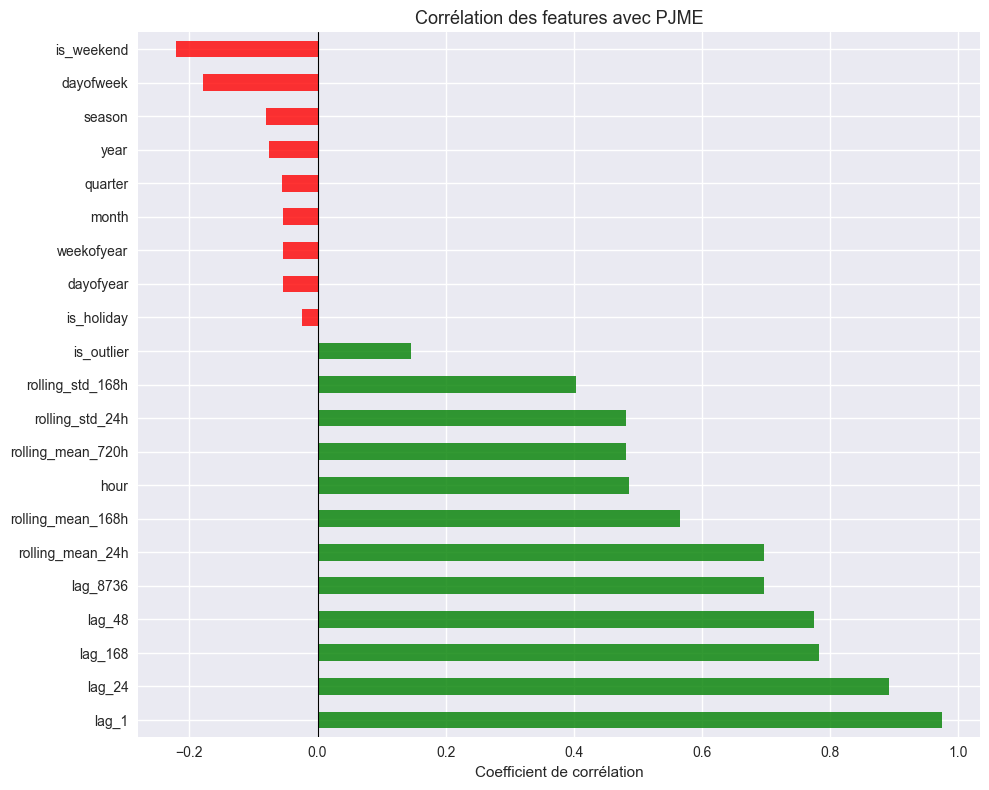

In [5]:
# ============================================================
# Suppression des NaN et analyse de corrélation
# ============================================================

print(f"Shape avant nettoyage : {df.shape}")
df = df.dropna()
print(f"Shape après nettoyage : {df.shape}")
print(f"Lignes supprimées     : {145366 - len(df):,}")

# --- Corrélation avec PJME ---
correlations = df.corr()['PJME'].drop('PJME').sort_values(ascending=False)

print(f"\n=== CORRÉLATION DES FEATURES AVEC PJME ===")
print(correlations.round(3))

# Visualisation
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', 
                  color=['green' if x > 0 else 'red' for x in correlations],
                  alpha=0.8)
plt.title('Corrélation des features avec PJME', fontsize=13)
plt.xlabel('Coefficient de corrélation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Téléchargement des données météo — Open-Meteo (gratuit, sans limite)
# Philadelphia, PA — point de référence pour la région PJM Est
# ============================================================

import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Configuration du client avec cache et retry automatique
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Paramètres de la requête
params = {
    "latitude"        : 39.9526,   # Philadelphia, PA
    "longitude"       : -75.1652,
    "start_date"      : "2003-01-01",
    "end_date"        : "2018-08-03",
    "hourly"          : ["temperature_2m", 
                         "relative_humidity_2m",
                         "wind_speed_10m", 
                         "cloud_cover"],
    "timezone"        : "America/New_York"
}

print("Téléchargement en cours...")
responses = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive", 
    params=params
)

response = responses[0]
print(f" Données reçues pour : {response.Latitude()}°N, {response.Longitude()}°E")

# Extraction des données horaires
hourly = response.Hourly()

df_meteo = pd.DataFrame({
    'datetime'    : pd.date_range(
                        start=pd.to_datetime(hourly.Time(), unit="s", utc=True)
                                  .tz_convert("America/New_York")
                                  .tz_localize(None),
                        periods=hourly.Variables(0).ValuesAsNumpy().shape[0],
                        freq="h"
                    ),
    'temp'        : hourly.Variables(0).ValuesAsNumpy(),
    'humidity'    : hourly.Variables(1).ValuesAsNumpy(),
    'windspeed'   : hourly.Variables(2).ValuesAsNumpy(),
    'cloudcover'  : hourly.Variables(3).ValuesAsNumpy()
})

df_meteo = df_meteo.set_index('datetime')
df_meteo = df_meteo.sort_index()

print(f"Shape : {df_meteo.shape}")
print(f"Période : {df_meteo.index.min()} → {df_meteo.index.max()}")
print(f"Valeurs manquantes :\n{df_meteo.isna().sum()}")
print(f"\nAperçu :")
print(df_meteo.head())

Téléchargement en cours...
 Données reçues pour : 39.964847564697266°N, -75.1676025390625°E
Shape : (136656, 4)
Période : 2002-12-31 23:00:00 → 2018-08-03 22:00:00
Valeurs manquantes :
temp          0
humidity      0
windspeed     0
cloudcover    0
dtype: int64

Aperçu :
                      temp   humidity  windspeed  cloudcover
datetime                                                    
2002-12-31 23:00:00  7.028  80.370117  12.984975        99.0
2003-01-01 00:00:00  7.278  78.729729  13.513193       100.0
2003-01-01 01:00:00  7.478  78.209023  10.041354       100.0
2003-01-01 02:00:00  7.178  83.839836   7.244860       100.0
2003-01-01 03:00:00  6.278  91.070274   7.127636       100.0


In [7]:
# ============================================================
# Fusion des données météo avec les données de consommation
# ============================================================

# Alignement des index — on garde uniquement les heures communes
df_merged = df.join(df_meteo, how='left')

print(f"Shape avant fusion : {df.shape}")
print(f"Shape après fusion : {df_merged.shape}")
print(f"\nValeurs manquantes après fusion :")
print(df_merged.isna().sum())
print(f"\nAperçu :")
print(df_merged.head())

Shape avant fusion : (136630, 22)
Shape après fusion : (136630, 26)

Valeurs manquantes après fusion :
PJME                  0
is_outlier            0
hour                  0
dayofweek             0
month                 0
quarter               0
year                  0
dayofyear             0
weekofyear            0
season                0
is_holiday            0
is_weekend            0
lag_1                 0
lag_24                0
lag_48                0
lag_168               0
lag_8736              0
rolling_mean_24h      0
rolling_mean_168h     0
rolling_mean_720h     0
rolling_std_24h       0
rolling_std_168h      0
temp                 20
humidity             20
windspeed            20
cloudcover           20
dtype: int64

Aperçu :
                        PJME  is_outlier  hour  dayofweek  month  quarter  \
Datetime                                                                    
2002-12-31 03:00:00  24574.0           0     3          1     12        4   
2002-12-31 04:00:00

## 5️ Finalisation des features

### Traitement des 20 NaN météo
Les 20 valeurs manquantes sont concentrées au début de la série (fin 2002).
On va les imputer par interpolation linéaire qui est appropriée pour des 
données continues comme la température.

### Features cycliques
L'heure 23 et l'heure 0 sont numériquement éloignées mais 
temporellement proches. On va encodé les variables cycliques avec sin/cos 
pour que les modèles comprennent cette circularité.

### Features d'interaction
On crée des combinaisons de features pour capturer des patterns complexes :
- `temp × hour` : l'impact de la température varie selon l'heure
- `temp × season` : l'impact de la température varie selon la saison
- `hour × is_weekend` : le profil journalier est différent le weekend

In [8]:
# ============================================================
# 5 — Finalisation des features
# ============================================================

# --- Interpolation des 20 NaN météo ---
df_merged[['temp', 'humidity', 'windspeed', 'cloudcover']] = \
    df_merged[['temp', 'humidity', 'windspeed', 'cloudcover']].interpolate(method='linear')

print(f"NaN après interpolation : {df_merged[['temp','humidity','windspeed','cloudcover']].isna().sum().sum()}")

# --- Features cycliques ---
# Heure
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged['hour'] / 24)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged['hour'] / 24)

# Jour de la semaine
df_merged['dow_sin'] = np.sin(2 * np.pi * df_merged['dayofweek'] / 7)
df_merged['dow_cos'] = np.cos(2 * np.pi * df_merged['dayofweek'] / 7)

# Mois
df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12)

# --- Features d'interaction ---
df_merged['temp_x_hour']    = df_merged['temp'] * df_merged['hour']
df_merged['temp_x_season']  = df_merged['temp'] * df_merged['season']
df_merged['hour_x_weekend'] = df_merged['hour'] * df_merged['is_weekend']

print(f"\n Features cycliques et interactions créées")
print(f"Shape final : {df_merged.shape}")
print(f"\nListe complète des features :")
for col in df_merged.columns:
    print(f"  - {col}")

NaN après interpolation : 80

 Features cycliques et interactions créées
Shape final : (136630, 35)

Liste complète des features :
  - PJME
  - is_outlier
  - hour
  - dayofweek
  - month
  - quarter
  - year
  - dayofyear
  - weekofyear
  - season
  - is_holiday
  - is_weekend
  - lag_1
  - lag_24
  - lag_48
  - lag_168
  - lag_8736
  - rolling_mean_24h
  - rolling_mean_168h
  - rolling_mean_720h
  - rolling_std_24h
  - rolling_std_168h
  - temp
  - humidity
  - windspeed
  - cloudcover
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - month_sin
  - month_cos
  - temp_x_hour
  - temp_x_season
  - hour_x_weekend


In [9]:
# ============================================================
# Diagnostic des NaN restants
# ============================================================

print("NaN par colonne :")
print(df_merged.isna().sum()[df_merged.isna().sum() > 0])

print(f"\nLocalisation des NaN météo :")
nan_rows = df_merged[df_merged['temp'].isna()]
print(f"Nombre de lignes : {len(nan_rows)}")
print(f"Période concernée :")
print(f"  Début : {nan_rows.index.min()}")
print(f"  Fin   : {nan_rows.index.max()}")

NaN par colonne :
temp             20
humidity         20
windspeed        20
cloudcover       20
temp_x_hour      20
temp_x_season    20
dtype: int64

Localisation des NaN météo :
Nombre de lignes : 20
Période concernée :
  Début : 2002-12-31 03:00:00
  Fin   : 2002-12-31 22:00:00


In [10]:
# ============================================================
# Recalcul des features d'interaction après interpolation
# ============================================================

df_merged['temp_x_hour']    = df_merged['temp'] * df_merged['hour']
df_merged['temp_x_season']  = df_merged['temp'] * df_merged['season']
df_merged['hour_x_weekend'] = df_merged['hour'] * df_merged['is_weekend']

# Vérification finale
total_nan = df_merged.isna().sum().sum()
print(f"NaN restants : {total_nan}")
print(f" Dataset propre !" if total_nan == 0 else " Il reste des NaN")
print(f"\nShape final : {df_merged.shape}")

NaN restants : 120
 Il reste des NaN

Shape final : (136630, 35)


In [11]:
# Diagnostic précis
print("NaN par colonne :")
print(df_merged.isna().sum()[df_merged.isna().sum() > 0])

print(f"\nLignes avec NaN :")
nan_rows = df_merged[df_merged.isna().any(axis=1)]
print(f"Nombre : {len(nan_rows)}")
print(f"Début  : {nan_rows.index.min()}")
print(f"Fin    : {nan_rows.index.max()}")
print(f"\nAperçu :")
print(nan_rows[['temp', 'humidity', 'windspeed', 'cloudcover']].head(10))

# Vérifier les valeurs autour
print(f"\nContexte autour du premier NaN :")
idx = nan_rows.index[0]
print(df_merged.loc[idx - pd.Timedelta(hours=2) : idx + pd.Timedelta(hours=2), 
                    ['temp', 'humidity', 'windspeed', 'cloudcover']])

NaN par colonne :
temp             20
humidity         20
windspeed        20
cloudcover       20
temp_x_hour      20
temp_x_season    20
dtype: int64

Lignes avec NaN :
Nombre : 20
Début  : 2002-12-31 03:00:00
Fin    : 2002-12-31 22:00:00

Aperçu :
                     temp  humidity  windspeed  cloudcover
Datetime                                                  
2002-12-31 03:00:00   NaN       NaN        NaN         NaN
2002-12-31 04:00:00   NaN       NaN        NaN         NaN
2002-12-31 05:00:00   NaN       NaN        NaN         NaN
2002-12-31 06:00:00   NaN       NaN        NaN         NaN
2002-12-31 07:00:00   NaN       NaN        NaN         NaN
2002-12-31 08:00:00   NaN       NaN        NaN         NaN
2002-12-31 09:00:00   NaN       NaN        NaN         NaN
2002-12-31 10:00:00   NaN       NaN        NaN         NaN
2002-12-31 11:00:00   NaN       NaN        NaN         NaN
2002-12-31 12:00:00   NaN       NaN        NaN         NaN

Contexte autour du premier NaN :
        

In [12]:
# ============================================================
# Remplissage des NaN en début de série (backward fill)
# ============================================================

# bfill : remplace les NaN par la prochaine valeur connue
df_merged[['temp', 'humidity', 'windspeed', 'cloudcover']] = \
    df_merged[['temp', 'humidity', 'windspeed', 'cloudcover']].bfill()

# Recalcul des features d'interaction
df_merged['temp_x_hour']   = df_merged['temp'] * df_merged['hour']
df_merged['temp_x_season'] = df_merged['temp'] * df_merged['season']
df_merged['hour_x_weekend']= df_merged['hour'] * df_merged['is_weekend']

# Vérification finale
total_nan = df_merged.isna().sum().sum()
print(f"NaN restants : {total_nan}")
print(f" Dataset propre " if total_nan == 0 else " Il reste des NaN")
print(f"Shape final : {df_merged.shape}")

NaN restants : 0
 Dataset propre 
Shape final : (136630, 35)


## Sauvegarde du dataset final

Le dataset final contient 35 features réparties en 5 catégories :

| Catégorie | Features |
|-----------|----------|
| Cible | PJME |
| Temporelles | hour, dayofweek, month, quarter, year, dayofyear, weekofyear, season |
| Binaires | is_outlier, is_holiday, is_weekend |
| Lags | lag_1, lag_24, lag_48, lag_168, lag_8736 |
| Rolling | rolling_mean_24h, 168h, 720h, rolling_std_24h, 168h |
| Météo | temp, humidity, windspeed, cloudcover |
| Cycliques | hour_sin/cos, dow_sin/cos, month_sin/cos |
| Interactions | temp_x_hour, temp_x_season, hour_x_weekend |

In [13]:
# ============================================================
# Sauvegarde du dataset final
# ============================================================

df_merged.to_csv('../data/processed/pjme_final.csv')

print(" Fichier sauvegardé : data/processed/pjme_final.csv")
print(f"Shape : {df_merged.shape}")
print(f"Période : {df_merged.index.min()} → {df_merged.index.max()}")

 Fichier sauvegardé : data/processed/pjme_final.csv
Shape : (136630, 35)
Période : 2002-12-31 03:00:00 → 2018-08-03 00:00:00
